# ML Training Notebook for Mueller Matrix Physical Realizability Prediction

In [38]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
import sys
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

# For deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F


# Add the parent directory to the path to access the utils module
sys.path.append('..')
from src.utils.file_paths import file_paths, TISSUE_DIMENSIONS
from src.utils.visualisation import plot_and_save_confusion_matrix

# Make sure results dir exists
resultspath = file_paths.model_save_path.parent / 'results'
resultspath.mkdir(parents=True, exist_ok=True)

labels = ['Not PR', 'PR']

In [39]:
# Set display options for better visibility
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Load the Prepared Data

In [40]:
# 1.1 Brain (as you already have)
X_brain_full = np.load(file_paths.brain_processed_path / 'X_brain.npy')
y_brain      = np.load(file_paths.brain_processed_path / 'y_brain.npy')
# use only first 12 MM elements
X_brain = X_brain_full[..., :12]

# 1.2 Cervix
X_cervix_full = np.load(file_paths.cervix_processed_path / 'merged_all_X.npy')
y_cervix      = np.load(file_paths.cervix_processed_path / 'merged_all_y.npy')
X_cervix = X_cervix_full[..., :12]

# 1.3 AFMMM
X_afmmm_full = np.load(file_paths.afmmm_processed_path  / 'merged_all_X.npy')
y_afmmm      = np.load(file_paths.afmmm_processed_path  / 'merged_all_y.npy')
X_afmmm = X_afmmm_full[..., :12]

# Print shapes for sanity
for name, X, y in [
    ('brain', X_brain, y_brain),
    ('cervix', X_cervix, y_cervix),
    ('afmmm', X_afmmm, y_afmmm)
]:
    print(f"{name:6s} → X: {X.shape},   y: {y.shape}")

brain  → X: (141, 388, 516, 12),   y: (141, 388, 516)
cervix → X: (16, 600, 800, 12),   y: (16, 600, 800)
afmmm  → X: (47, 500, 500, 12),   y: (47, 500, 500)


## 2. Prepare Data for Training

In [41]:
# Flatten each to (n_samples * H * W, 12) and (n_samples * H * W,)
def flatten(X, y):
    ns, H, W, F = X.shape
    return X.reshape(-1, F), y.reshape(-1)

Xb_flat, yb_flat = flatten(X_brain, y_brain)
Xc_flat, yc_flat = flatten(X_cervix, y_cervix)
Xa_flat, ya_flat = flatten(X_afmmm, y_afmmm)

# Concatenate across all pixels
X_flat = np.vstack([Xb_flat, Xc_flat, Xa_flat])
y_flat = np.concatenate([yb_flat, yc_flat, ya_flat])

print(f"After merge → X_flat: {X_flat.shape}, y_flat: {y_flat.shape}")

After merge → X_flat: (47659328, 12), y_flat: (47659328,)


|## 3. Explore Data Balance

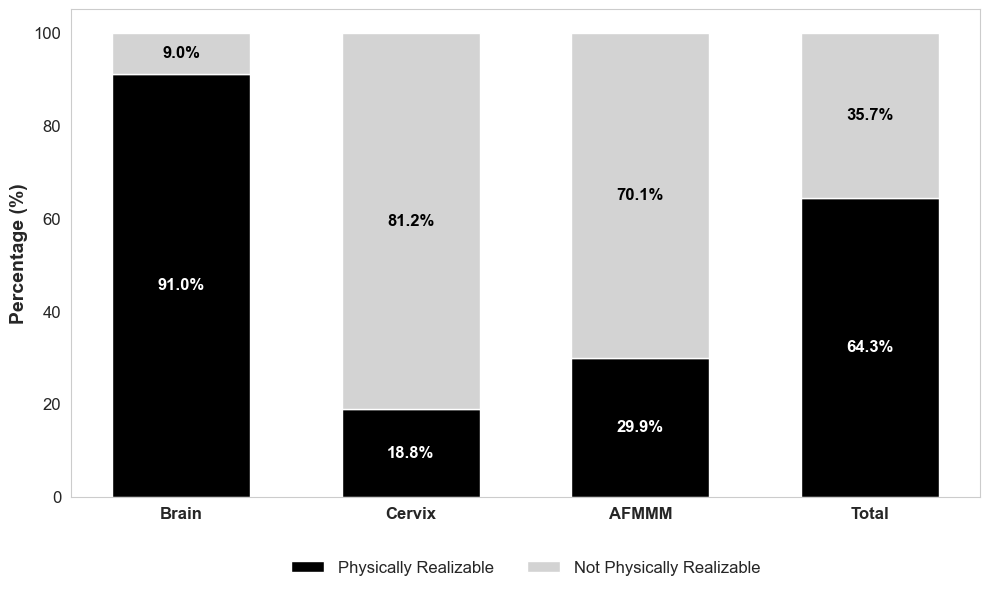

Brain   → 25,700,742 PR pixels (91.0%)
Cervix  → 1,444,115 PR pixels (18.8%)
AFMMM   → 3,514,706 PR pixels (29.9%)
Total   → 30,659,563 PR pixels (64.3%)



In [42]:
import matplotlib.pyplot as plt

# Get flat counts
def get_class_distribution(y):
    y_flat = y.reshape(-1)
    values, counts = np.unique(y_flat, return_counts=True)
    dist = dict(zip(values, counts))
    total = sum(counts)
    pct_0 = dist.get(0, 0) / total * 100
    pct_1 = dist.get(1, 0) / total * 100
    return pct_0, pct_1, total

# Get per-tissue distributions
brain_0, brain_1, brain_total = get_class_distribution(y_brain)
cervix_0, cervix_1, cervix_total = get_class_distribution(y_cervix)
afmmm_0, afmmm_1, afmmm_total = get_class_distribution(y_afmmm)

# Compute totals
total_0 = (brain_0 * brain_total + cervix_0 * cervix_total + afmmm_0 * afmmm_total) / (brain_total + cervix_total + afmmm_total)
total_1 = (brain_1 * brain_total + cervix_1 * cervix_total + afmmm_1 * afmmm_total) / (brain_total + cervix_total + afmmm_total)

# Data
data_labels = ['Brain', 'Cervix', 'AFMMM', 'Total']
pct_realizable = [brain_1, cervix_1, afmmm_1, total_1]
pct_not_realizable = [brain_0, cervix_0, afmmm_0, total_0]

# Plot
x = np.arange(len(data_labels))
width = 0.6

plt.figure(figsize=(10, 6))

# Draw bars with new colors
bars_realizable = plt.bar(
    x,
    pct_realizable,
    width,
    label='Physically Realizable',
    color='black'
)

bars_not_realizable = plt.bar(
    x,
    pct_not_realizable,
    width,
    bottom=pct_realizable,
    label='Not Physically Realizable',
    color='#d3d3d3'  # light gray
)

# Labels
plt.ylabel('Percentage (%)', fontsize=14, fontweight='bold')
plt.title('', fontsize=16, fontweight='bold')
plt.xticks(x, data_labels, fontsize=12, fontweight='bold')
plt.yticks(fontsize=12)
plt.grid(False)

# Add text labels
for i in range(len(data_labels)):
    # White text on black bar (Realizable)
    plt.text(
        x[i],
        pct_realizable[i] / 2,
        f'{pct_realizable[i]:.1f}%',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='white'
    )
    # Black text on gray bar (Not Realizable)
    plt.text(
        x[i],
        pct_realizable[i] + (pct_not_realizable[i] / 2),
        f'{pct_not_realizable[i]:.1f}%',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='black'
    )

plt.ylim(0, 105)
plt.legend(
    fontsize=12,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
    frameon=False
)
plt.tight_layout()
plt.show()

# after you do:
brain_0, brain_1, brain_total = get_class_distribution(y_brain)
cervix_0, cervix_1, cervix_total = get_class_distribution(y_cervix)
afmmm_0, afmmm_1, afmmm_total = get_class_distribution(y_afmmm)

# Compute PR pixel counts
brain_pr_count  = int(brain_1/100 * brain_total)
cervix_pr_count = int(cervix_1/100 * cervix_total)
afmmm_pr_count  = int(afmmm_1/100 * afmmm_total)
total_pixels    = brain_total + cervix_total + afmmm_total
total_pr_count  = brain_pr_count + cervix_pr_count + afmmm_pr_count
total_pr_pct    = (total_pr_count / total_pixels) * 100

# Print them
print(f"Brain   → {brain_pr_count:,} PR pixels ({brain_1:.1f}%)")
print(f"Cervix  → {cervix_pr_count:,} PR pixels ({cervix_1:.1f}%)")
print(f"AFMMM   → {afmmm_pr_count:,} PR pixels ({afmmm_1:.1f}%)")
print(f"Total   → {total_pr_count:,} PR pixels ({total_pr_pct:.1f}%)\n")

In [44]:
# after you do:
brain_0, brain_1, brain_total = get_class_distribution(y_brain)
cervix_0, cervix_1, cervix_total = get_class_distribution(y_cervix)
afmmm_0, afmmm_1, afmmm_total = get_class_distribution(y_afmmm)

# Compute PR pixel counts
brain_pr_count  = int(brain_1/100 * brain_total)
cervix_pr_count = int(cervix_1/100 * cervix_total)
afmmm_pr_count  = int(afmmm_1/100 * afmmm_total)
total_pixels    = brain_total + cervix_total + afmmm_total
total_pr_count  = brain_pr_count + cervix_pr_count + afmmm_pr_count
total_pr_pct    = (total_pr_count / total_pixels) * 100

# Print them
print(f"Brain   → {brain_pr_count:,} PR pixels ({brain_1:.1f}%)")
print(f"Cervix  → {cervix_pr_count:,} PR pixels ({cervix_1:.1f}%)")
print(f"AFMMM   → {afmmm_pr_count:,} PR pixels ({afmmm_1:.1f}%)")
print(f"Total   → {total_pr_count:,} PR pixels ({total_pr_pct:.1f}%)\n")

Brain   → 25,700,742 PR pixels (91.0%)
Cervix  → 1,444,115 PR pixels (18.8%)
AFMMM   → 3,514,706 PR pixels (29.9%)
Total   → 30,659,563 PR pixels (64.3%)



## 4. Split Data for Training, Validation, and Testing

Overall class distribution:
Class 0.0: 16999765 (35.67%)
Class 1.0: 30659563 (64.33%)


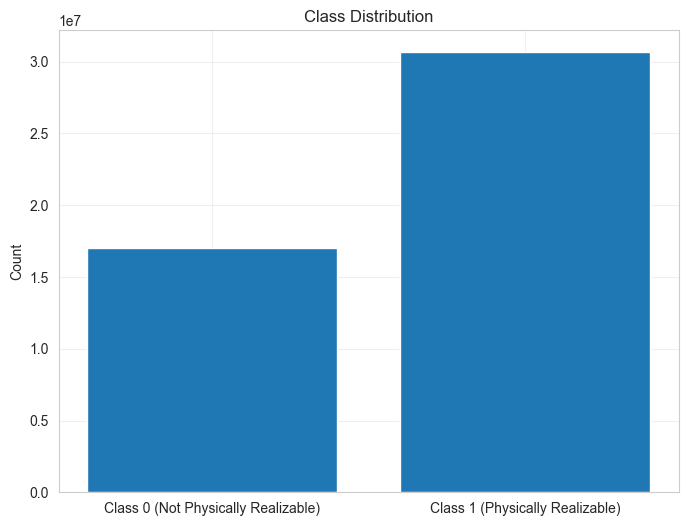

In [45]:
# Check class balance before splitting
unique_values, counts = np.unique(y_flat, return_counts=True)
class_distribution = dict(zip(unique_values, counts))

print("Overall class distribution:")
for value, count in class_distribution.items():
    print(f"Class {value}: {count} ({count / len(y_flat) * 100:.2f}%)")

plt.figure(figsize=(8, 6))
plt.bar(['Class 0 (Not Physically Realizable)', 'Class 1 (Physically Realizable)'], 
        [class_distribution.get(0, 0), class_distribution.get(1, 0)])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()


In [46]:
# Sample only 10% of the data to make training more manageable

In [47]:
# Subsample data (10% of total) with stratification to maintain class distribution
# We'll use stratified sampling to maintain the same class distribution

# Create mask for 0 and 1 classes
mask_0 = (y_flat == 0)
mask_1 = (y_flat == 1)

# Get indices for each class
indices_0 = np.where(mask_0)[0]
indices_1 = np.where(mask_1)[0]

# Select 10% from each class
sample_size_0 = len(indices_0) // 10
sample_size_1 = len(indices_1) // 10

# Randomly sample indices
np.random.seed(42)
sampled_indices_0 = np.random.choice(indices_0, size=sample_size_0, replace=False)
sampled_indices_1 = np.random.choice(indices_1, size=sample_size_1, replace=False)

# Combine indices
sampled_indices = np.concatenate([sampled_indices_0, sampled_indices_1])

# Shuffle the combined indices
np.random.shuffle(sampled_indices)

# Subset the data
X_flat_sampled = X_flat[sampled_indices]
y_flat_sampled = y_flat[sampled_indices]

print(f"Original data size: {len(X_flat):,} samples")
print(f"Sampled data size: {len(X_flat_sampled):,} samples ({len(X_flat_sampled)/len(X_flat)*100:.1f}% of original)")

# Check class distribution after sampling
unique_values, counts = np.unique(y_flat_sampled, return_counts=True)
class_distribution = dict(zip(unique_values, counts))

print("\nSampled data class distribution:")
for value, count in class_distribution.items():
    print(f"Class {value}: {count} ({count / len(y_flat_sampled) * 100:.2f}%)")

Original data size: 47,659,328 samples
Sampled data size: 4,765,932 samples (10.0% of original)

Sampled data class distribution:
Class 0.0: 1699976 (35.67%)
Class 1.0: 3065956 (64.33%)


In [48]:
# Split the sampled data into training, validation, and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_flat_sampled, y_flat_sampled, test_size=0.2, random_state=42, stratify=y_flat_sampled
)

# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Check class distribution in each split
for name, y_data in [('Training', y_train), ('Validation', y_val), ('Testing', y_test)]:
    unique_values, counts = np.unique(y_data, return_counts=True)
    class_dist = dict(zip(unique_values, counts))
    print(f"\n{name} set class distribution:")
    for value, count in class_dist.items():
        print(f"Class {value}: {count} ({count / len(y_data) * 100:.2f}%)")


X_train shape: (2859558, 12), y_train shape: (2859558,)
X_val shape: (953187, 12), y_val shape: (953187,)
X_test shape: (953187, 12), y_test shape: (953187,)

Training set class distribution:
Class 0.0: 1019985 (35.67%)
Class 1.0: 1839573 (64.33%)

Validation set class distribution:
Class 0.0: 339996 (35.67%)
Class 1.0: 613191 (64.33%)

Testing set class distribution:
Class 0.0: 339995 (35.67%)
Class 1.0: 613192 (64.33%)


# LightGBM classifier

In [49]:
# %% md
## 5  Per-pixel classification with an MLP
# We now build a feed-forward network that takes the 12 partial Mueller-matrix
# elements of a *single pixel* and predicts the boolean “physically realizable”
# label.  This lives completely separate from the U-Net segmentation branch.

# %% 5.0 Data loaders ---------------------------------------------------------
# wrap flat numpy arrays in TensorDataset
train_dataset_cls = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32),
)
val_dataset_cls = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32),
)
test_dataset_cls = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32),
)

# large batches are fine for tabular data
batch_size_cls   = 8_192
train_loader_cls = DataLoader(train_dataset_cls, batch_size=batch_size_cls, shuffle=True)
val_loader_cls   = DataLoader(val_dataset_cls,   batch_size=batch_size_cls)
test_loader_cls  = DataLoader(test_dataset_cls,  batch_size=batch_size_cls)

# %% 5.1 MLP architecture -----------------------------------------------------
class PixelMLP(nn.Module):
    def __init__(self, in_features: int = 12, hidden_sizes=(128, 64, 32)):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden_sizes:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(0.30),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))   # single-logit output
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)                 # raw logits (no sigmoid!)

clf_model = PixelMLP().to(device)

# %% 5.2 Loss, optimiser, scheduler ------------------------------------------
# positives ≈ 91 %  → weight minority 0-class higher
pos_fraction_cls = y_train.mean()
neg_fraction_cls = 1.0 - pos_fraction_cls
pos_weight_val   = neg_fraction_cls / pos_fraction_cls
criterion_cls    = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_val], device=device)
)
print(f"MLP pos_weight = {pos_weight_val:.2f}")

optimizer_cls = optim.Adam(clf_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_cls = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cls, mode="min", factor=0.1, patience=3, verbose=True
)

# %% 5.3 Training / validation helpers ---------------------------------------
def run_epoch(model, loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    y_true, y_pred = [], []

    with torch.set_grad_enabled(train):
        for data, target in loader:
            data, target = data.to(device), target.to(device)

            if train:
                optimizer_cls.zero_grad()

            logits = model(data)
            loss   = criterion_cls(logits, target)

            if train:
                loss.backward()
                optimizer_cls.step()

            total_loss += loss.item() * data.size(0)

            probs = torch.sigmoid(logits)
            y_true.append(target.cpu().numpy())
            y_pred.append((probs > 0.5).float().cpu().numpy())

    y_true = np.concatenate(y_true).ravel()
    y_pred = np.concatenate(y_pred).ravel()

    avg_loss = total_loss / len(loader.dataset)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    return avg_loss, acc, prec, rec, f1

# %% 5.4 Train the MLP --------------------------------------------------------
best_val = float("inf")
epochs_cls = 15
for epoch in range(1, epochs_cls + 1):
    tr_loss, tr_acc, _, _, _ = run_epoch(clf_model, train_loader_cls, train=True)
    vl_loss, vl_acc, vl_prec, vl_rec, vl_f1 = run_epoch(clf_model, val_loader_cls, train=False)
    scheduler_cls.step(vl_loss)

    print(f"[MLP Epoch {epoch:02d}/{epochs_cls}] "
          f"train loss {tr_loss:.4f} • val loss {vl_loss:.4f} "
          f"• val F1 {vl_f1:.4f}")

    if vl_loss < best_val:
        best_val = vl_loss
        torch.save(clf_model.state_dict(), file_paths.model_save_path / "best_pixel_mlp.pth")

# %% 5.5-bis MLP Confusion Matrix (and save) -----------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make sure results directory exists
resultspath = file_paths.model_save_path.parent / 'results'
resultspath.mkdir(parents=True, exist_ok=True)

# Gather true labels & MLP preds
y_true_list, y_pred_list = [], []
clf_model.eval()
with torch.no_grad():
    for data, target in test_loader_cls:
        data = data.to(device)
        logits = clf_model(data)
        probs  = torch.sigmoid(logits).cpu().numpy().ravel()
        preds  = (probs > 0.5).astype(int)
        y_pred_list.append(preds)
        y_true_list.append(target.cpu().numpy().ravel())

y_true_all = np.concatenate(y_true_list)
y_pred_all = np.concatenate(y_pred_list)

# Plot
plot_and_save_confusion_matrix(
    y_true=y_test.ravel(),
    y_pred=y_pred_all,  # from your MLP loop
    labels=labels,
    title="Pixel-MLP Confusion Matrix",
    save_path=resultspath / 'mlp_confusion_matrix.png'
)

MLP pos_weight = 0.55


/Users/chaechae/Desktop/EP_Code/pr_prediction/.venv/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[MLP Epoch 01/15] train loss 0.1126 • val loss 0.0579 • val F1 0.9752
[MLP Epoch 02/15] train loss 0.0638 • val loss 0.0504 • val F1 0.9790
[MLP Epoch 03/15] train loss 0.0576 • val loss 0.0517 • val F1 0.9744
[MLP Epoch 04/15] train loss 0.0552 • val loss 0.0467 • val F1 0.9789
[MLP Epoch 05/15] train loss 0.0536 • val loss 0.0462 • val F1 0.9786
[MLP Epoch 06/15] train loss 0.0524 • val loss 0.0462 • val F1 0.9778
[MLP Epoch 07/15] train loss 0.0522 • val loss 0.0486 • val F1 0.9759
[MLP Epoch 08/15] train loss 0.0513 • val loss 0.0445 • val F1 0.9799
[MLP Epoch 09/15] train loss 0.0507 • val loss 0.0444 • val F1 0.9792
[MLP Epoch 10/15] train loss 0.0501 • val loss 0.0443 • val F1 0.9799
[MLP Epoch 11/15] train loss 0.0500 • val loss 0.0440 • val F1 0.9794
[MLP Epoch 12/15] train loss 0.0498 • val loss 0.0437 • val F1 0.9794
[MLP Epoch 13/15] train loss 0.0494 • val loss 0.0456 • val F1 0.9770
[MLP Epoch 14/15] train loss 0.0492 • val loss 0.0435 • val F1 0.9792
[MLP Epoch 15/15] tr

# Xgboost

In [50]:
# %% md
### 5-bis  LightGBM Gradient-Boosted Trees

import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train, weight=np.where(y_train == 0, pos_weight_val, 1.0))
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

params = dict(
    objective   = "binary:logistic",
    eval_metric = "logloss",
    eta         = 0.05,
    max_depth   = 7,
    subsample   = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = pos_weight_val,   # handles imbalance
    nthread     = -1,
    seed        = 42,
)

print("🔧  Training XGBoost …")
bst = xgb.train(
    params,
    dtrain,
    num_boost_round      = 1000,
    evals                = [(dval, "val")],
    early_stopping_rounds= 50,
    verbose_eval         = 100,
)

print("\n🧪  XGBoost test metrics")
y_hat = (bst.predict(dtest) > 0.5).astype(int)
print(f"accuracy  {accuracy_score(y_test, y_hat):.4f}")
print(f"precision {precision_score(y_test, y_hat):.4f}")
print(f"recall    {recall_score(y_test, y_hat):.4f}")
print(f"F1        {f1_score(y_test, y_hat):.4f}")

# save + reload
bst.save_model(str(file_paths.model_save_path / "pixel_xgb.json"))
# later:  xgb.Booster().load_model("pixel_xgb.json")

# %% 5-ter XGBoost Confusion Matrix (and save) ---------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create results directory once
resultspath = file_paths.model_save_path.parent / 'results'
resultspath.mkdir(parents=True, exist_ok=True)

# %% 5-bis  XGBoost Gradient-Boosted Trees
import xgboost as xgb
# … your existing XGBoost training code …

print("\n🧪  XGBoost test metrics")
y_hat = (bst.predict(dtest) > 0.5).astype(int)
print(f"accuracy  {accuracy_score(y_test, y_hat):.4f}")
# … other metrics …

bst.save_model(str(file_paths.model_save_path / "pixel_xgb.json"))

# %% 5-ter  XGBoost Confusion Matrix (and save)

# Compute confusion matrix
cm_xgb = confusion_matrix(y_test.ravel(), y_hat)


# XGBoost
plot_and_save_confusion_matrix(
    y_true=y_test.ravel(),
    y_pred=y_hat,      # from bst.predict
    labels=labels,
    title="XGBoost Confusion Matrix",
    save_path=resultspath / 'xgb_confusion_matrix.png'
)

🔧  Training XGBoost …
[0]	val-logloss:0.60942
[100]	val-logloss:0.07831
[200]	val-logloss:0.06702
[300]	val-logloss:0.06311
[400]	val-logloss:0.06118
[500]	val-logloss:0.05997
[600]	val-logloss:0.05911
[700]	val-logloss:0.05852
[800]	val-logloss:0.05810
[900]	val-logloss:0.05776
[999]	val-logloss:0.05753

🧪  XGBoost test metrics
accuracy  0.9760
precision 0.9824
recall    0.9802
F1        0.9813

🧪  XGBoost test metrics
accuracy  0.9760


# CatBoostClassifier

In [51]:
!pip install pytorch-tabnet -q    # ← run once if not installed

In [52]:
from catboost import CatBoostClassifier, Pool

train_pool = Pool(X_train, y_train, weight=np.where(y_train == 0, pos_weight_val, 1.0))
val_pool   = Pool(X_val,   y_val)

cat = CatBoostClassifier(
    loss_function       = "Logloss",
    depth               = 8,
    learning_rate       = 0.05,
    iterations          = 2000,
    l2_leaf_reg         = 3.0,
    random_seed         = 42,
    eval_metric         = "Logloss",
    verbose             = 200,
    early_stopping_rounds = 100,
    class_weights       = [pos_weight_val, 1.0],   # index 0 → class 0
)

print("🔧  Training CatBoost …")
cat.fit(train_pool, eval_set=val_pool)

print("\n🧪  CatBoost test metrics")
y_hat = (cat.predict_proba(X_test)[:, 1] > 0.5).astype(int)
print(f"accuracy  {accuracy_score(y_test, y_hat):.4f}")
print(f"precision {precision_score(y_test, y_hat):.4f}")
print(f"recall    {recall_score(y_test, y_hat):.4f}")
print(f"F1        {f1_score(y_test, y_hat):.4f}")

# save + reload
cat.save_model(file_paths.model_save_path / "pixel_catboost.cbm")

# %% 5-terbis  CatBoostClassifier (and confusion matrix)
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# … your existing CatBoost training code …

# After metrics:
y_pred_cb = (cat.predict_proba(X_test)[:, 1] > 0.5).astype(int)

# Confusion matrix
plot_and_save_confusion_matrix(
    y_true=y_test.ravel(),
    y_pred=y_pred_cb,  # from cat.predict_proba
    labels=labels,
    title="CatBoost Confusion Matrix",
    save_path=resultspath / 'catboost_confusion_matrix.png'
)

🔧  Training CatBoost …
0:	learn: 0.5615244	test: 0.5669477	best: 0.5669477 (0)	total: 149ms	remaining: 4m 57s
200:	learn: 0.0531119	test: 0.0677279	best: 0.0677279 (200)	total: 14.5s	remaining: 2m 9s
400:	learn: 0.0469665	test: 0.0605017	best: 0.0605017 (400)	total: 28.6s	remaining: 1m 53s
600:	learn: 0.0444242	test: 0.0577614	best: 0.0577614 (600)	total: 42.7s	remaining: 1m 39s
800:	learn: 0.0431383	test: 0.0564718	best: 0.0564718 (799)	total: 56.2s	remaining: 1m 24s
1000:	learn: 0.0424091	test: 0.0557702	best: 0.0557702 (1000)	total: 1m 9s	remaining: 1m 9s
1200:	learn: 0.0421120	test: 0.0555012	best: 0.0555012 (1200)	total: 1m 22s	remaining: 54.7s
1400:	learn: 0.0420499	test: 0.0554471	best: 0.0554471 (1400)	total: 1m 34s	remaining: 40.6s
1600:	learn: 0.0417413	test: 0.0551872	best: 0.0551872 (1599)	total: 1m 47s	remaining: 26.8s
1800:	learn: 0.0415947	test: 0.0550642	best: 0.0550642 (1800)	total: 2m	remaining: 13.3s
1999:	learn: 0.0415187	test: 0.0549996	best: 0.0549996 (1999)	total